In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import os

In [2]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [4]:
dataset_path = "../dataset"

In [5]:
os.listdir(dataset_path)

['iris-setosa', 'iris-versicolour', 'iris-virginica']

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [7]:
train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 338 images belonging to 3 classes.


In [8]:
validation_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 83 images belonging to 3 classes.


In [9]:
print(train_data.class_indices)


{'iris-setosa': 0, 'iris-versicolour': 1, 'iris-virginica': 2}


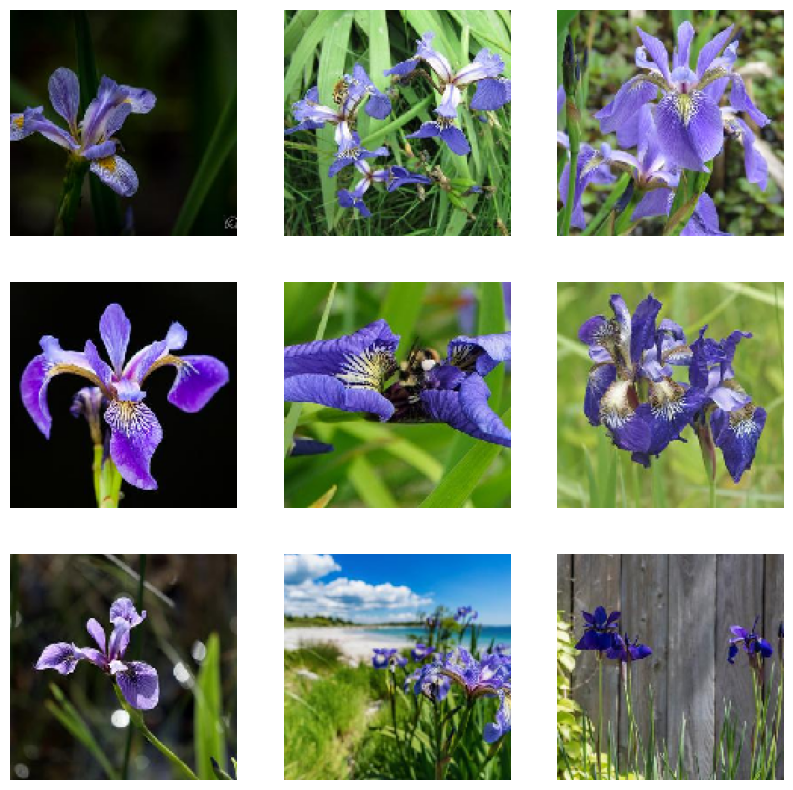

In [10]:
# Visualize Sample Images
images, labels = next(train_data)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')

plt.show()

In [11]:
model = Sequential([
    
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(150,150,3)
    ),
    
    MaxPooling2D(2,2),
    
    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),
    
    MaxPooling2D(2,2),
    
    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),
    
    MaxPooling2D(2,2),
    
    Flatten(),
    
    Dense(
        128,
        activation='relu'
    ),
    
    Dropout(0.5),
    
    Dense(
        3,
        activation='softmax'
    )
])

f:\CodeAlpha_Iris_Image_Classification\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,739 (18.42 MB)

 Trainable params: 4,828,739 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=30
)

Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - accuracy: 0.8994 - loss: 0.2754 - val_accuracy: 0.6506 - val_loss: 1.1520
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.9290 - loss: 0.1903 - val_accuracy: 0.6386 - val_loss: 1.9555
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - accuracy: 0.9112 - loss: 0.2694 - val_accuracy: 0.5904 - val_loss: 1.2104
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - accuracy: 0.9172 - loss: 0.2161 - val_accuracy: 0.6386 - val_loss: 1.1583
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 0.9260 - loss: 0.1770 - val_accuracy: 0.6627 - val_loss: 1.4935
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 161ms/step - accuracy: 0.9438 - loss: 0.1556 - val_accuracy: 0.6265 - val_loss: 1.7198
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 158ms/step - accuracy: 0.9556 - loss: 0.1351 - val_accuracy: 0.6627 - val_loss: 1.1759
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step - accuracy: 0.9408 - loss: 0.1661 - val_accuracy: 0.

In [28]:
model.save("../models/iris_cnn_model.h5")

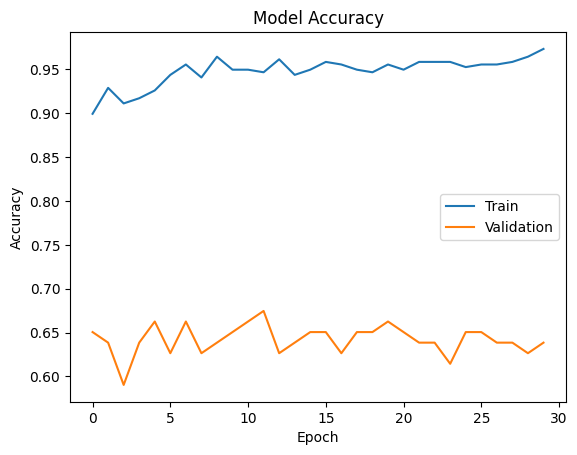

In [29]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

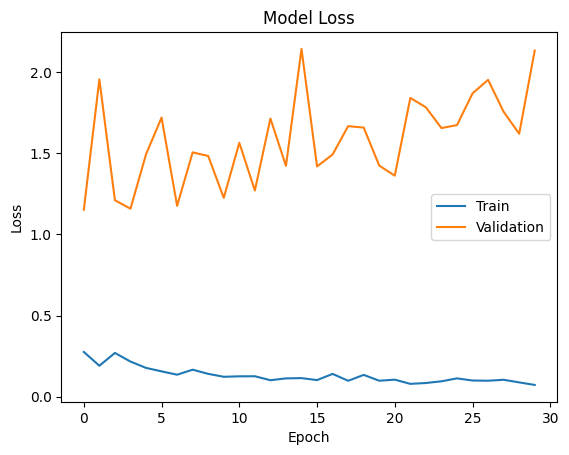

In [30]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [31]:
loss, accuracy = model.evaluate(validation_data)

print("Validation Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6386 - loss: 2.1335
Validation Accuracy: 0.6385542154312134


In [35]:
predictions = model.predict(validation_data)

predicted_classes = np.argmax(predictions, axis=1)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


In [33]:
true_classes = validation_data.classes

In [34]:
class_labels = list(validation_data.class_indices.keys())

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_labels
    )
)

                  precision    recall  f1-score   support

     iris-setosa       0.12      0.08      0.10        13
iris-versicolour       0.66      0.91      0.76        53
  iris-virginica       0.50      0.06      0.11        17

        accuracy                           0.60        83
       macro avg       0.43      0.35      0.32        83
    weighted avg       0.54      0.60      0.52        83



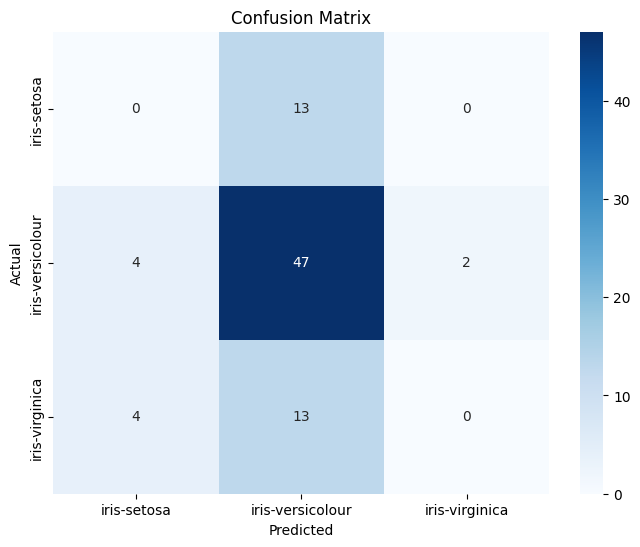

In [36]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()